# OVERVIEW

This notebooks serves as an example of how to use the code defined in the src folder

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt

from black_scholes import black_scholes_call, black_scholes_put, contract_price, greeks, implied_volatility, full_iv_analysis
from monte_carlo import simulate_gbm_path, simulate_gbm_paths, monte_carlo_call_price
from plotting import plot_greeks, plot_convergence, plot_iv_vs_realised

/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


We start with the question, "Given a ticker price, strike price, volatility, time period and risk-free interest rate, how much should a call/put option cost?"
This is answered using Black-Scholes

In [2]:
S_val = 220 #stock price
K_val = 200 #strike price
T_val = 0.25 #time in years
r_val = 0.05 #risk-free interest rate
sigma_val = 0.3 #annualised volatility of the ticker

call = black_scholes_call(S_val, K_val, T_val, r_val, sigma_val)
put = black_scholes_put(S_val, K_val, T_val, r_val, sigma_val)

print(f"Call Price: ${call:.2f}")
print(f"Put Price ${put:.2f}")

Call Price: $26.81
Put Price $4.32


So per stock of this ticker, it would cost $26.81 to agree to buy at $200 in 3 months time and cost $4.32 per stock to sell at $200 in 3 months time

We now look onto the greeks, the set of partial derivatives of the call price function, with respect to each of its variables (except strike price which we fix constant).
$$\Delta = \frac{\partial C}{\partial S} = N(d_1)$$
$$\Gamma = \frac{\partial^2 C}{\partial S^2} = \frac{N'(d_1)}{S\sigma\sqrt{T}}$$
$$\nu = \frac{\partial C}{\partial \sigma} = S\sqrt{T}\,N'(d_1)$$
$$\Theta = -\frac{\partial C}{\partial T} = -\frac{S\,N'(d_1)\,\sigma}{2\sqrt{T}} - rKe^{-rT}N(d_2)$$
$$\rho = \frac{\partial C}{\partial r} = KTe^{-rT}N(d_2)$$
Where $N(\cdot)$ is the standard normal cumulative distribution function, $N'(\cdot)$ is the standard normal probability density function, and:
$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

In [3]:
from black_scholes import greeks
g = greeks(S_val, K_val, T_val, r_val, sigma_val) #for the same ticker values as set out above

for name, value in g.items():
    print(f"{name.capitalize():8s}: {value:.4f}")

Delta   : 0.7863
Gamma   : 0.0088
Vega    : 32.0256
Theta   : -26.5247
Rho     : 36.5466


We now plot these greeks as a function of stock price, to gain insights into the mathematics of options.

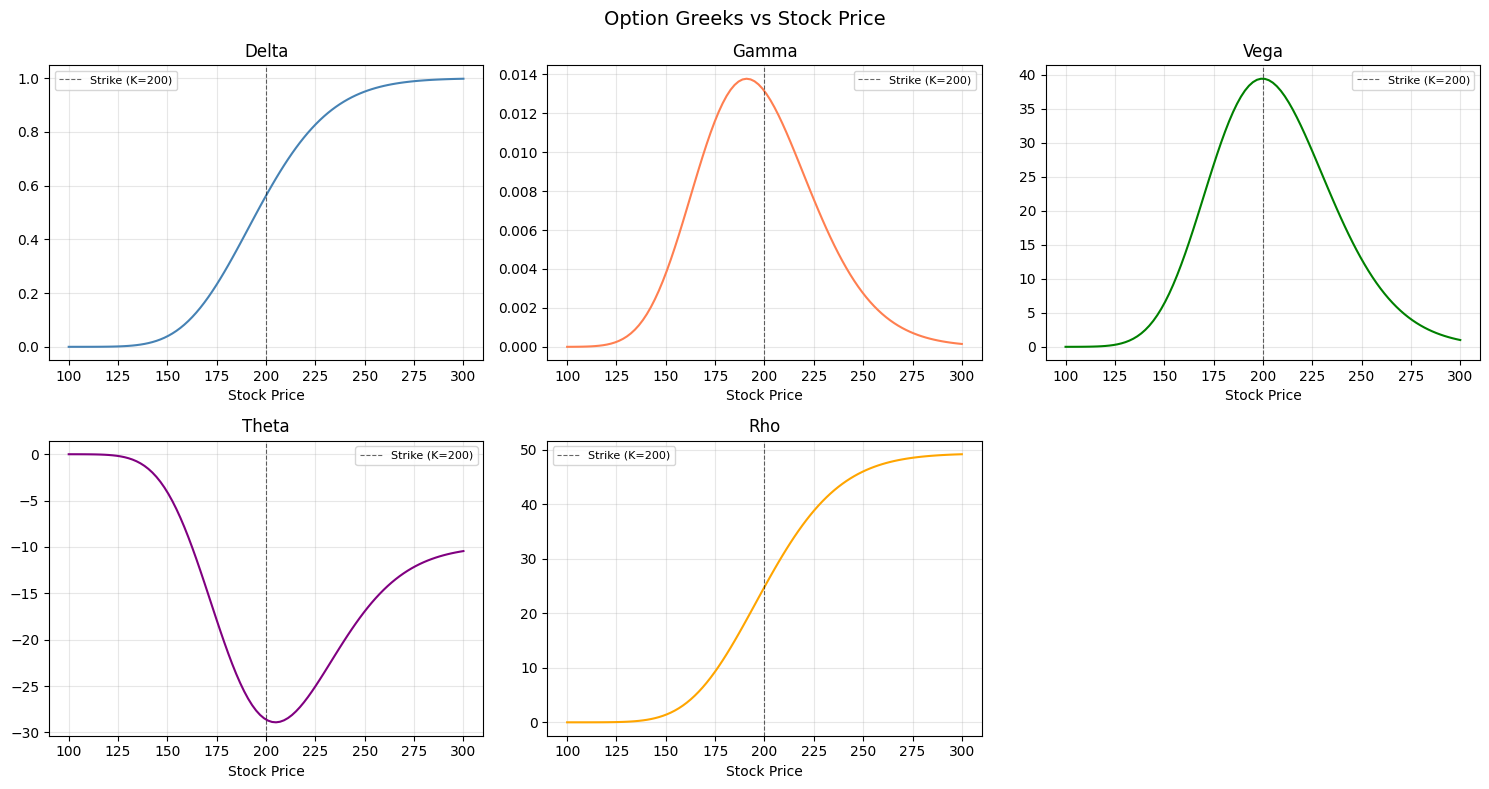

In [4]:
from plotting import plot_greeks

plot_greeks(greeks, K_val=200, T_val=0.25, r_val=0.05, sigma_val=0.3)

The greeks offer many insights to the theory of options. Briefly, we notice that $\theta (S)$ has a minimum around the stock price, so we have the 'most time value' to lose right at the strike price. Similarly, $\nu(S)$ reaches a max at the strike price, so we maximum uncertainty when we do not whether we make a profit or not.

We now move onto monte carlo methods. We aim to approximate the solution to Geometric Brownian motion SDE by discretising. This gives us one path, which is totally random, and changes each time we run the code. We plot many many paths to see the general direction and compare to the analytic Black-Scholes solution.

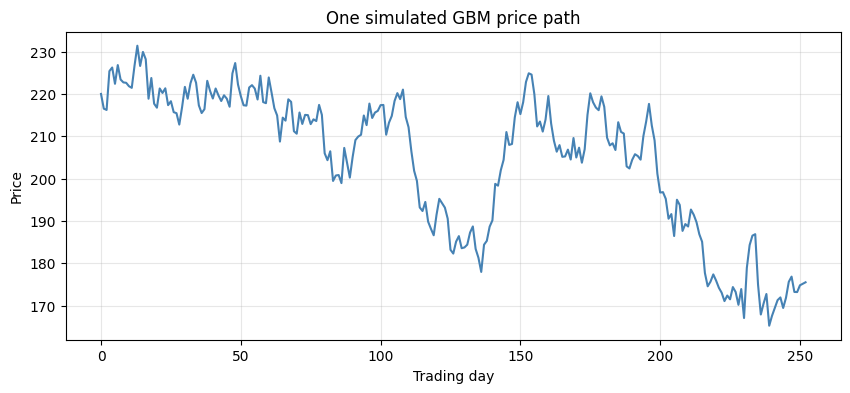

In [5]:
path = simulate_gbm_path(S0=220, mu=0.08, sigma=0.30, T=1, n_steps=252)

plt.figure(figsize=(10, 4))
plt.plot(path, color='steelblue')
plt.title('One simulated GBM price path')
plt.xlabel('Trading day')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.show()

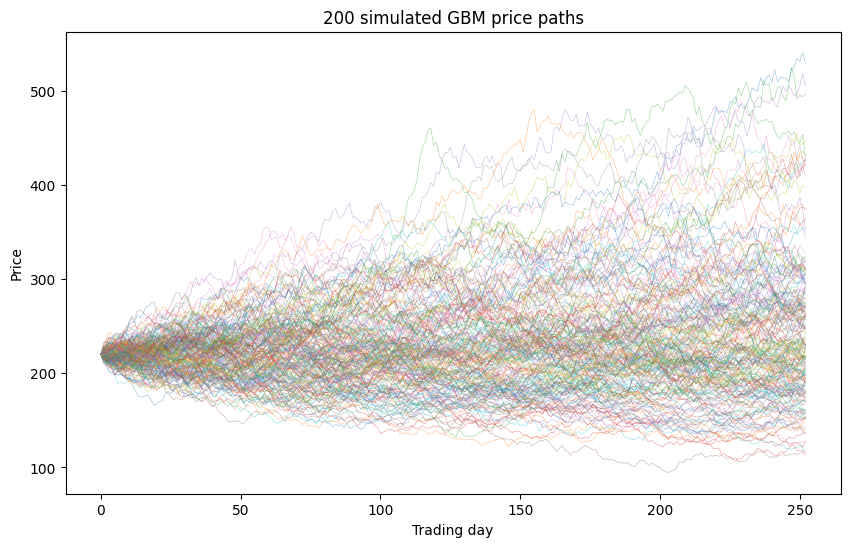

Final prices range: $113.53 to $529.97


In [6]:
paths = simulate_gbm_paths(S0=220, mu=0.08, sigma=0.30, T=1, n_steps=252, n_paths=200)

plt.figure(figsize=(10, 6))
for i in range(200):
    plt.plot(paths[i], linewidth=0.5, alpha=0.4)
plt.title('200 simulated GBM price paths')
plt.xlabel('Trading day')
plt.ylabel('Price')
plt.show()

print(f"Final prices range: ${paths[:, -1].min():.2f} to ${paths[:, -1].max():.2f}")

We now calculate the average of all of these paths, which is the monte carlo price, and compare with the price given by Black-Scholes (just as at the very start)

In [7]:
bs_price = black_scholes_call(S_val, K_val, T_val, r_val, sigma_val)
mc_price = monte_carlo_call_price(S0=S_val, K=K_val, T=T_val, r=r_val, sigma=sigma_val)

print(f"Black-Scholes price: ${bs_price:.4f}")
print(f"Monte Carlo price:   ${mc_price:.4f}")
print(f"Difference:          ${abs(bs_price - mc_price):.4f}")

Black-Scholes price: $26.8051
Monte Carlo price:   $26.6783
Difference:          $0.1268


We also have a convergence plot, to see how the difference between them changes as we run more paths:

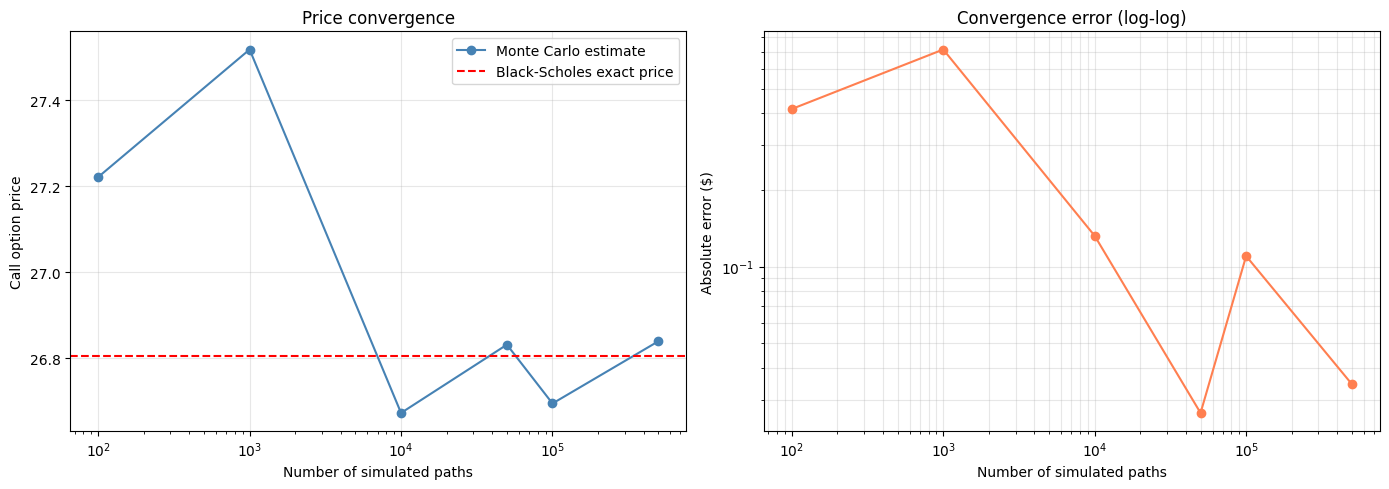

In [8]:
plot_convergence(
    monte_carlo_call_price,
    bs_price,
    S0=S_val, K=K_val, T=T_val, r=r_val, sigma=sigma_val
)

We see that the more paths we simulate, the closer the average gets. This is due to the law of large numbers. The number of points can be chosen manually setting path_counts=[set of points you want] in plot_convergence

## COMMENT ABOUT DATA USED FOR IMPLIED VOLATILITY
We end by discussing implied volatility. First we show that given an option price, and all other variables, we can work backwards and find what the volatility must've been. This is called the implied volatility. At the very end we do this with real market data. There is limitations with this due to limits of free data. We have to use potentially stale trades ('lastPrice' may not be 100% accurate) and short time to expiry can create an unusually large volatility gap. This is due Yahoo Finance unreliability to return live bid/ask quotes. We choose options with longer times to expiry in order to combat this and produce numerical values similar to what has been empirically published. The difference between the realised probability and implied volatility is called the volatility premium and is often used to trade.

In [9]:
from black_scholes import implied_volatility

true_sigma = 0.30
market_price = black_scholes_call(S_val=220, K_val=200, T_val=0.25, r_val=0.05, sigma_val=true_sigma)
#we pretend that we do not know the volatility and work backwards to calculate it
recovered_sigma = implied_volatility(market_price, S_val=220, K_val=200, T_val=0.25, r_val=0.05)

print(f"True volatility:      {true_sigma:.4f}")
print(f"Recovered volatility: {recovered_sigma:.4f}")

True volatility:      0.3000
Recovered volatility: 0.3000


[*********************100%***********************]  1 of 1 completed


Ticker:              AMZN
Current price:       $230.86
Strike used:         $230.00
Expiry:              2026-08-14 (T=0.0440 years)
Option lastPrice:    $10.50  (not a live quote, see above markdown comment)
Implied volatility:  0.5089 (50.89%)
Realised volatility: 0.3153 (31.53%)
Difference:          19.36 percentage points


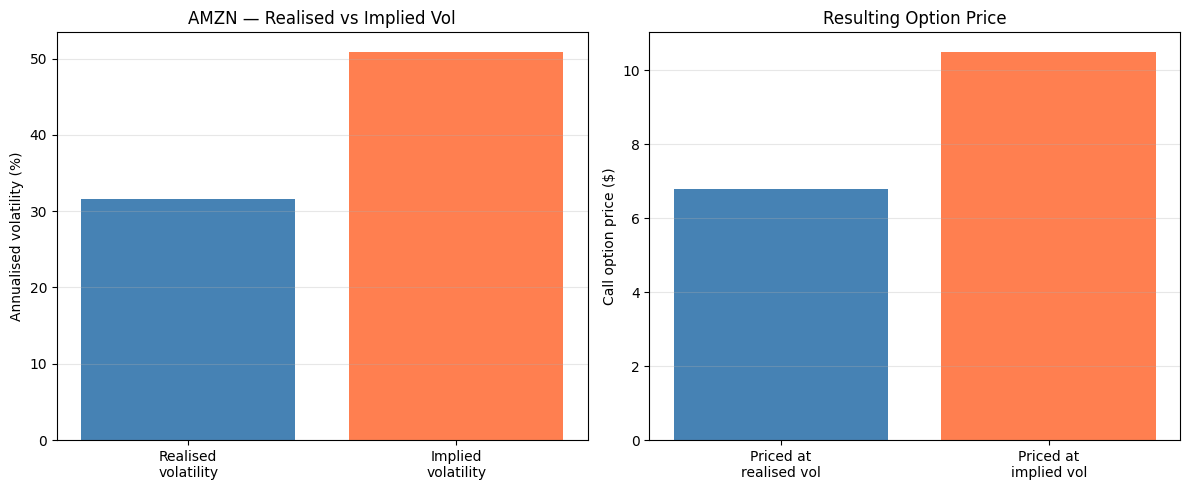

Volatility risk premium: 19.36 percentage points
Price difference:       $3.72


In [10]:
from black_scholes import full_iv_analysis
from plotting import plot_iv_vs_realised

ticker = "AMZN"

result = full_iv_analysis(ticker, expiry_index=5)

plot_iv_vs_realised(ticker=result['ticker'], iv=result['iv'], realised_vol=result['realised_vol'], S_val=result['S_val'], K_val=result['K_val'], T_val=result['T_val'], r_val=result['r_val'])